### Overview
- The objective of this capstone program is to provide learners with hands-on, project-based experience in the fields of Advanced Data Science, Machine Learning, Deep Learning, NLP, and Generative AI. Each capstone project will challenge participants to apply theoretical concepts to real-world datasets, equipping them with the necessary skills to solve industry-relevant problems.

- Learners will engage in the end-to-end development of data-driven solutions, including data cleaning, feature engineering, model building, evaluation, and deployment. The projects are designed to help participants build a strong portfolio that showcases their ability to tackle AI and Data Science challenges.

#### Project Statement
- E-commerce platforms generate vast amounts of user-generated content, including product reviews, ratings, and purchase behavior data. When analyzed effectively, this information can help businesses improve product recommendations, detect fake reviews, and enhance the overall customer experience. However, extracting insights from unstructured textual reviews and integrating them with structured metadata poses significant challenges.

- This capstone program will focus on building predictive models and NLP solutions to:

  - Analyze customer sentiment based on product reviews
  - Predict product ratings using both text and structured data
  - Detect spam or fake reviews by identifying unnatural language patterns
  - Summarize product reviews to provide concise insights for buyers

- By leveraging machine learning, NLP, and deep learning techniques, learners will address real-world challenges in customer feedback analysis, fraud detection, and AI-driven product insights.

#### Data Description:
- The dataset used in this capstone project is sourced from an e-commerce review platform, containing both structured and unstructured data:

###### Structured data:
- marketplace: Region where the review was posted
- customer_id: Unique identifier for the customer
- product_id: Unique identifier for the product
- product_category: Category of the product (e.g., Apparel, Electronics, Home & Kitchen)
- star_rating: Rating given by the customer on a 1–5 scale
- helpful_votes & total_votes: Indicators of how helpful a review was deemed by other users
- verified_purchase: Indicates whether the customer purchased the product

###### Unstructured data:
- review_headline: Short title of the review
- review_body: Full-text review provided by the customer
- review_date: Date the review was posted

This dataset offers multiple opportunities for predictive modeling, natural language processing (NLP), and sentiment analysis, making it ideal for hands-on AI applications in real-world scenarios.

#### Steps to Perform

In [1]:
#!pip install -q pandas matplotlib seaborn
#!pip install scipy
#!pip install -q scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

#### Section 1: Data analysis and preprocessing
1. Data preprocessing with NumPy & Pandas
    - Load and explore the dataset using Pandas DataFrames
    - Handle missing values in the review_body, star_rating, and verified_purchase columns
    - Convert review_date to datetime format and extract time-based trends
    - Clean and transform review_body to remove HTML tags and unnecessary characters

In [3]:
# Check if the file exists before trying to read it
file_path = "../data/amazon_reviews_us_Apparel_v1_00.csv"
if not os.path.exists(file_path):
    print(f"File '{file_path}' does not exist. Exiting...")
    exit(1)  # Exit the program with an error code
else:
    print(f"File '{file_path}' exists. Proceeding to read the data...")

File '../data/amazon_reviews_us_Apparel_v1_00.csv' exists. Proceeding to read the data...


In [4]:
df = pd.read_csv(file_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 15 columns):
 #   Column             Non-Null Count    Dtype
---  ------             --------------    -----
 0   marketplace        1048575 non-null  str  
 1   customer_id        1048575 non-null  int64
 2   review_id          1048575 non-null  str  
 3   product_id         1048575 non-null  str  
 4   product_parent     1048575 non-null  int64
 5   product_title      1048575 non-null  str  
 6   product_category   1048575 non-null  str  
 7   star_rating        1048575 non-null  int64
 8   helpful_votes      1048575 non-null  int64
 9   total_votes        1048575 non-null  int64
 10  vine               1048575 non-null  str  
 11  verified_purchase  1048575 non-null  str  
 12  review_headline    1048569 non-null  str  
 13  review_body        1048105 non-null  str  
 14  review_date        1048491 non-null  str  
dtypes: int64(5), str(10)
memory usage: 120.0 MB


In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

df.isnull().sum()


marketplace            0
customer_id            0
review_id              0
product_id             0
product_parent         0
product_title          0
product_category       0
star_rating            0
helpful_votes          0
total_votes            0
vine                   0
verified_purchase      0
review_headline        6
review_body          470
review_date           84
dtype: int64

In [6]:
df.fillna({"star_rating": 0}, inplace=True)
df.fillna({"review_body": ""}, inplace=True)
df.fillna({"review_headline": ""}, inplace=True)
df.fillna({"verified_purchase": "N"}, inplace=True)
df.fillna({"review_date": "01/01/1900"}, inplace=True) # Set a default date for missing values

df.isnull().sum()

marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        0
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      0
review_body          0
review_date          0
dtype: int64

In [7]:
df["review_date"] = pd.to_datetime(df["review_date"], errors='coerce')

# order by review_date
df = df.sort_values(by="review_date")

df = df.drop(columns=["review_year", "review_month", "review_day"], errors='ignore')

# extract time-based features
df["review_year"] = df["review_date"].dt.year.fillna(1900).astype(int)
df["review_month"] = df["review_date"].dt.month.fillna(1).astype(int)
df["review_day"] = df["review_date"].dt.day.fillna(1).astype(int)
df["review_month_2014"] = df["review_month"].where(df["review_year"] == 2014)
df["review_month_2015"] = df["review_month"].where(df["review_year"] == 2015)

df.isnull().sum()

C:\Users\15012\AppData\Local\Temp\ipykernel_27104\1718652872.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["review_date"] = pd.to_datetime(df["review_date"], errors='coerce')


marketplace               0
customer_id               0
review_id                 0
product_id                0
product_parent            0
product_title             0
product_category          0
star_rating               0
helpful_votes             0
total_votes               0
vine                      0
verified_purchase         0
review_headline           0
review_body               0
review_date              84
review_year               0
review_month              0
review_day                0
review_month_2014    893802
review_month_2015    154883
dtype: int64

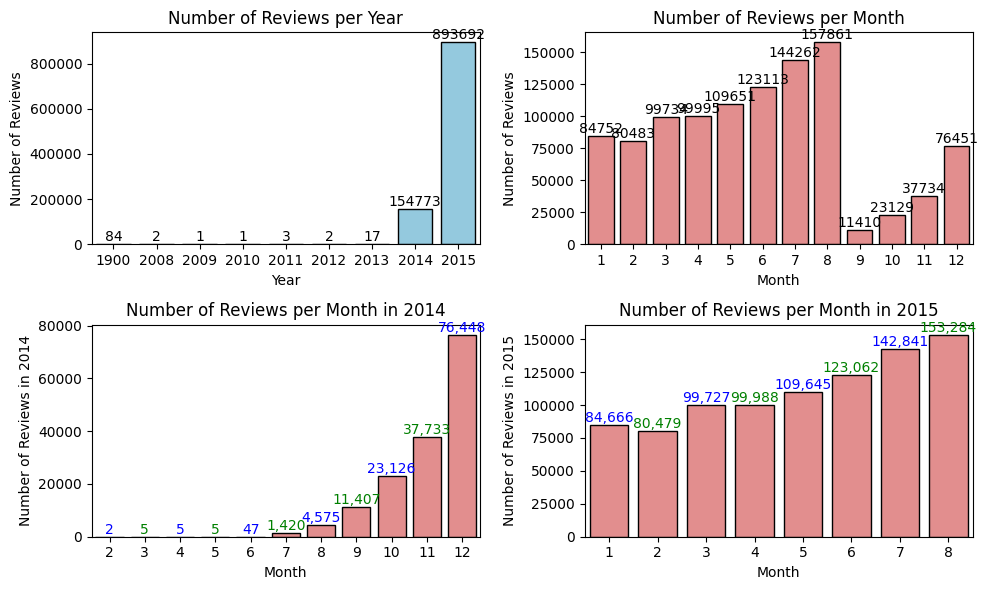

In [8]:

plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
sns.barplot(x=df["review_year"].value_counts().sort_index().index, y=df["review_year"].value_counts().sort_index().values, color='skyblue', edgecolor='black')
# show the count of reviews on top of each bar
for i, (index, row) in enumerate(df["review_year"].value_counts().sort_index().items()):
    plt.text(i, row, str(row), ha='center', va='bottom')
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews per Year")

plt.subplot(2, 2, 2)
sns.barplot(x=df["review_month"].value_counts().sort_index().index, y=df["review_month"].value_counts().sort_index().values, color='lightcoral', edgecolor='black')
# show the count of reviews on top of each bar
for i, (index, row) in enumerate(df["review_month"].value_counts().sort_index().items()):
    plt.text(i, row, str(row), ha='center', va='bottom')
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews per Month")

plt.subplot(2, 2, 3)
# filter where reivew_year = 2014
sns.barplot(x=df["review_month_2014"].value_counts().sort_index().index.astype(int), y=df["review_month_2014"].value_counts().sort_index().values, color='lightcoral', edgecolor='black')
# show the count of reviews on top of each bar
for i, (index, row) in enumerate(df["review_month_2014"].value_counts().sort_index().items()):
    # format the row value with commas for thousands
    formatted_row = "{:,}".format(row)
    # alternately color the text for better visibility
    if i % 2 == 0:        
        plt.text(i, row, formatted_row, ha='center', va='bottom', color='blue')
    else:
        plt.text(i, row, formatted_row, ha='center', va='bottom', color='green')
plt.xlabel("Month")
plt.ylabel("Number of Reviews in 2014")
plt.title("Number of Reviews per Month in 2014")

plt.subplot(2, 2, 4)
# filter where reivew_year = 2015
sns.barplot(x=df["review_month_2015"].value_counts().sort_index().index.astype(int), y=df["review_month_2015"].value_counts().sort_index().values, color='lightcoral', edgecolor='black')
# show the count of reviews on top of each bar
for i, (index, row) in enumerate(df["review_month_2015"].value_counts().sort_index().items()):
    # format the row value with commas for thousands
    formatted_row = "{:,}".format(row)
    # alternately color the text for better visibility
    if i % 2 == 0:        
        plt.text(i, row, formatted_row, ha='center', va='bottom', color='blue')
    else:
        plt.text(i, row, formatted_row, ha='center', va='bottom', color='green')
plt.xlabel("Month")
plt.ylabel("Number of Reviews in 2015")
plt.title("Number of Reviews per Month in 2015")

plt.tight_layout()
plt.show()



In [9]:
url_re = re.compile(r"https?://\S+|www\.\S+")
html_re = re.compile(r"<.*?>")

def clean_text(s: str) -> str:
    s = s.lower().strip()
    s = url_re.sub(" ", s)
    s = html_re.sub(" ", s)
    s = re.sub(r"[^a-z0-9\s\.,!?\'\"\-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["review_body_clean"] = df["review_body"].apply(clean_text)

2. Exploratory Data Analysis (EDA) with Pandas & visualization libraries
    - Compute summary statistics for ratings and helpful votes
    - Create correlation matrices to analyze relationships between star_rating, helpful_votes, and verified_purchase
    - Identify the most and least reviewed products using grouping and aggregation
    - Visualize the distribution of ratings across product categories using Matplotlib and Seaborn

In [10]:
# compute summary statistics for ratings and helpful votes
print("Summary Statistics for Star Ratings and helpful votes:")
print(df[["star_rating", "helpful_votes"]].describe())


Summary Statistics for Star Ratings and helpful votes:
        star_rating  helpful_votes
count  1.048575e+06   1.048575e+06
mean   4.023326e+00   1.018677e+00
std    1.331466e+00   8.425199e+00
min    1.000000e+00   0.000000e+00
25%    3.000000e+00   0.000000e+00
50%    5.000000e+00   0.000000e+00
75%    5.000000e+00   1.000000e+00
max    5.000000e+00   3.675000e+03


In [11]:
# Create correlation matrices to analyze relationships between star_rating, helpful_votes, and verified_purchase
df["verified_purchase"] = df["verified_purchase"].map({"Y": 1, "N": 0})

corr_matrix = df[["star_rating", "helpful_votes", "verified_purchase"]].corr()
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                   star_rating  helpful_votes  verified_purchase
star_rating           1.000000      -0.006635          -0.006804
helpful_votes        -0.006635       1.000000          -0.019984
verified_purchase    -0.006804      -0.019984           1.000000


In [12]:
# Identify the most and least reviewed products using grouping and aggregation
product_review_counts = df.groupby("product_title").size().sort_values(ascending=False)
most_reviewed_product = product_review_counts.idxmax()
least_reviewed_product = product_review_counts.idxmin()
print(f"Most Reviewed Product Title: {most_reviewed_product} with {product_review_counts.max()} reviews")
print(f"Least Reviewed Product Title: {least_reviewed_product} with {product_review_counts.min()} reviews")

product_review_counts = df.groupby("product_id").size().sort_values(ascending=False)
most_reviewed_product = product_review_counts.idxmax()
least_reviewed_product = product_review_counts.idxmin()
print(f"\nMost Reviewed Product ID: {most_reviewed_product} with {product_review_counts.max()} reviews")
print(f"Least Reviewed Product ID: {least_reviewed_product} with {product_review_counts.min()} reviews")

Most Reviewed Product Title: Cocoship 50s Retro Vintage Floral Print White Polka One Piece Swimwear Monokinis(FBA) with 1318 reviews
Least Reviewed Product Title: # No Filter Graphic T-Shirt with 1 reviews

Most Reviewed Product ID: B00LMI9A6Y with 808 reviews
Least Reviewed Product ID: B00L4EQN8E with 1 reviews


C:\Users\15012\AppData\Local\Temp\ipykernel_27104\2561039234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="star_rating", data=df, palette="viridis", edgecolor='black')


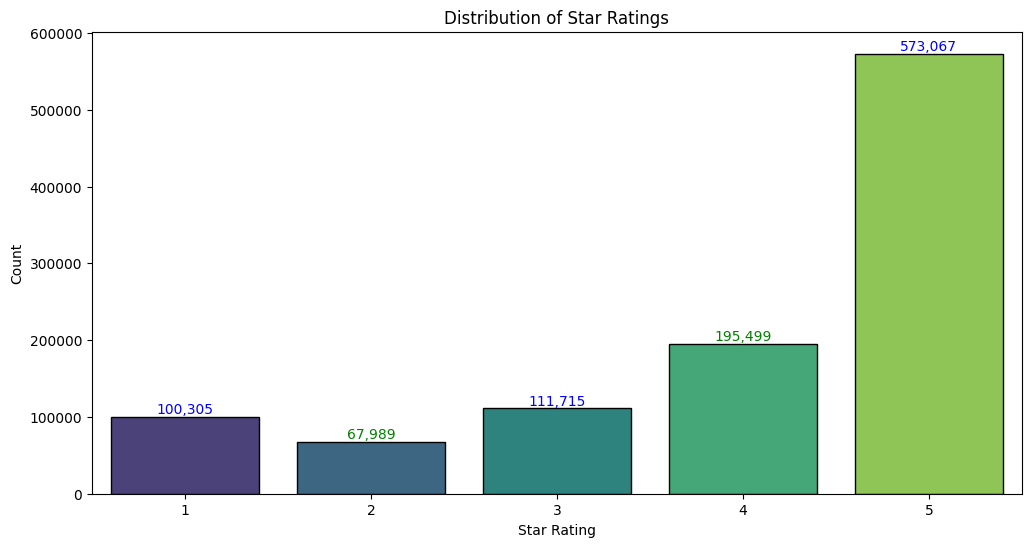

In [13]:
# Visualize the distribution of ratings across product categories using Matplotlib and Seaborn
plt.figure(figsize=(12, 6))
sns.countplot(x="star_rating", data=df, palette="viridis", edgecolor='black')
for i, (index, row) in enumerate(df["star_rating"].value_counts().sort_index().items()):
    formatted_row = "{:,}".format(row)
    if i % 2 == 0:        
        plt.text(i, row, formatted_row, ha='center', va='bottom', color='blue')
    else:
        plt.text(i, row, formatted_row, ha='center', va='bottom', color='green')
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.title("Distribution of Star Ratings")
plt.show()

3. Statistical analysis & probability
    - Calculate measures of central tendency and dispersion for star_rating
    - Perform hypothesis testing to assess whether verified purchases result in more positive reviews
    - Apply Bayesian probability to predict the likelihood of a review being helpful based on historical data

In [14]:
# central tendency for star_rating
mean_rating = df["star_rating"].mean()
median_rating = df["star_rating"].median()
mode_rating = df["star_rating"].mode()[0]

# and dispersion for star_rating
range_rating = df["star_rating"].max() - df["star_rating"].min()
variance_rating = df["star_rating"].var()
std_rating = df["star_rating"].std()

print("Central Tendency for Star Ratings:")
print(f"Mean: {mean_rating:.2f}, Median: {median_rating}, Mode: {mode_rating}")
print("Dispersion for Star Ratings:")
print(f"Range: {range_rating}, Variance: {variance_rating:.2f}, Standard Deviation: {std_rating:.2f}")


Central Tendency for Star Ratings:
Mean: 4.02, Median: 5.0, Mode: 5
Dispersion for Star Ratings:
Range: 4, Variance: 1.77, Standard Deviation: 1.33


In [16]:
# Perform hypothesis testing to assess whether verified purchases result in more positive reviews
from scipy.stats import ttest_ind
verified_reviews = df[df["verified_purchase"] == 1]["star_rating"]
unverified_reviews = df[df["verified_purchase"] == 0]["star_rating"]
t_stat, p_value = ttest_ind(verified_reviews, unverified_reviews, equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject the null hypothesis: Verified purchases have a statistically significant impact on star ratings.")
else:
    print("Fail to reject the null hypothesis: No statistically significant impact of verified purchases on star ratings.")



T-statistic: -6.7322, P-value: 0.0000
Reject the null hypothesis: Verified purchases have a statistically significant impact on star ratings.


In [19]:
# Apply Bayesian probability to predict the likelihood of a review being helpful based on historical data
# Check this block for validity

# Create a binary target variable for helpful reviews (e.g., helpful_votes > 0)
df["helpful_review"] = (df["helpful_votes"] > 0).astype(int)

# Use review_body_clean as the feature and helpful_review as the target

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["review_body_clean"])
y = df["helpful_review"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report for Naive Bayes Model:")
print(classification_report(y_test, y_pred))


Classification Report for Naive Bayes Model:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83    155580
           1       0.50      0.33      0.40     54135

    accuracy                           0.74    209715
   macro avg       0.64      0.61      0.62    209715
weighted avg       0.71      0.74      0.72    209715



4. Data visualization for business insights
    - Create bar charts to show the most popular product categories based on review counts
    - Use box plots to analyze the distribution of star_rating across categories
    - Develop heatmaps to visualize correlations between helpful_votes, total_votes, and verified_purchase
    - Plot time-series line charts to track changes in review patterns over the years

In [23]:
print(f"Total number of rows in the dataset: {df.shape[0]}, Total number of rows for Category Apparel: {df[df['product_category'] == 'Apparel'].shape[0]}")

Total number of rows in the dataset: 1048575, Total number of rows for Category Apparel: 1048575


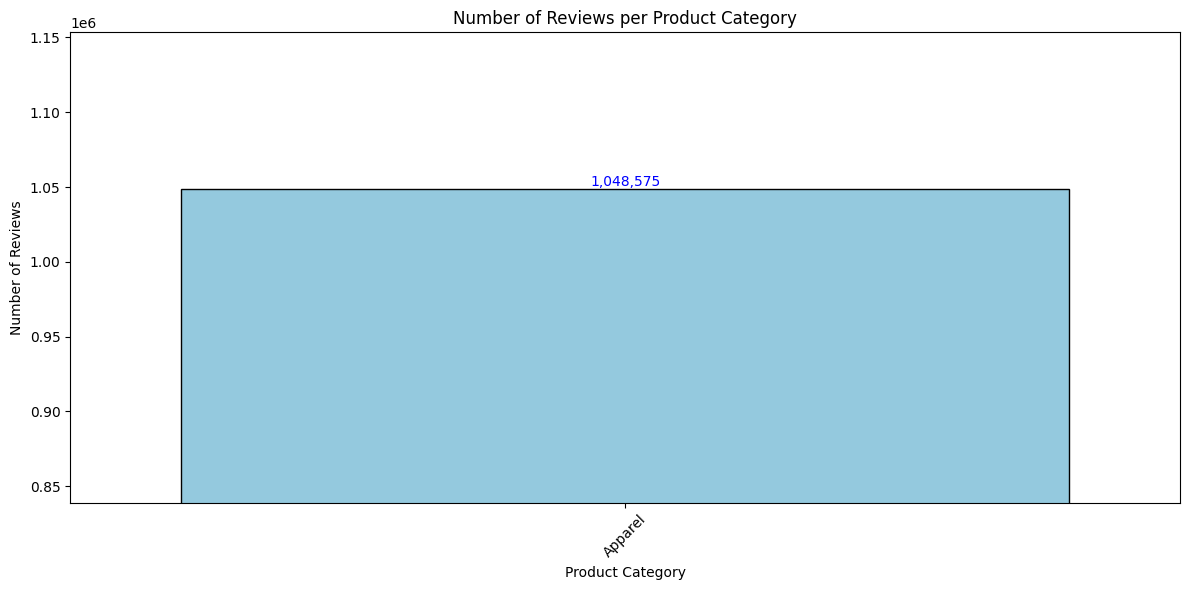

In [25]:
# Bar plot to show the most populat product categories based on the number of reviews
# As all the review are for Apparel category, the plot will show only one bar.
plt.figure(figsize=(12, 6))
sns.barplot(x=df["product_category"].value_counts().index, y=df["product_category"].value_counts().values, color='skyblue', edgecolor='black')
# show the count of reviews on top of each bar
for i, (index, row) in enumerate(df["product_category"].value_counts().items()):
    formatted_row = "{:,}".format(row)
    if i % 2 == 0:        
        plt.text(i, row, formatted_row, ha='center', va='bottom', color='blue')
    else:
        plt.text(i, row, formatted_row, ha='center', va='bottom', color='green')
plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews per Product Category")
plt.xticks(rotation=45)
# use margin to show only top portion of the bar plot as there is only one category and the count is high.
apparel_count = df["product_category"].value_counts().values[0]
plt.ylim(apparel_count * 0.8, apparel_count * 1.1)
plt.tight_layout()
plt.show()

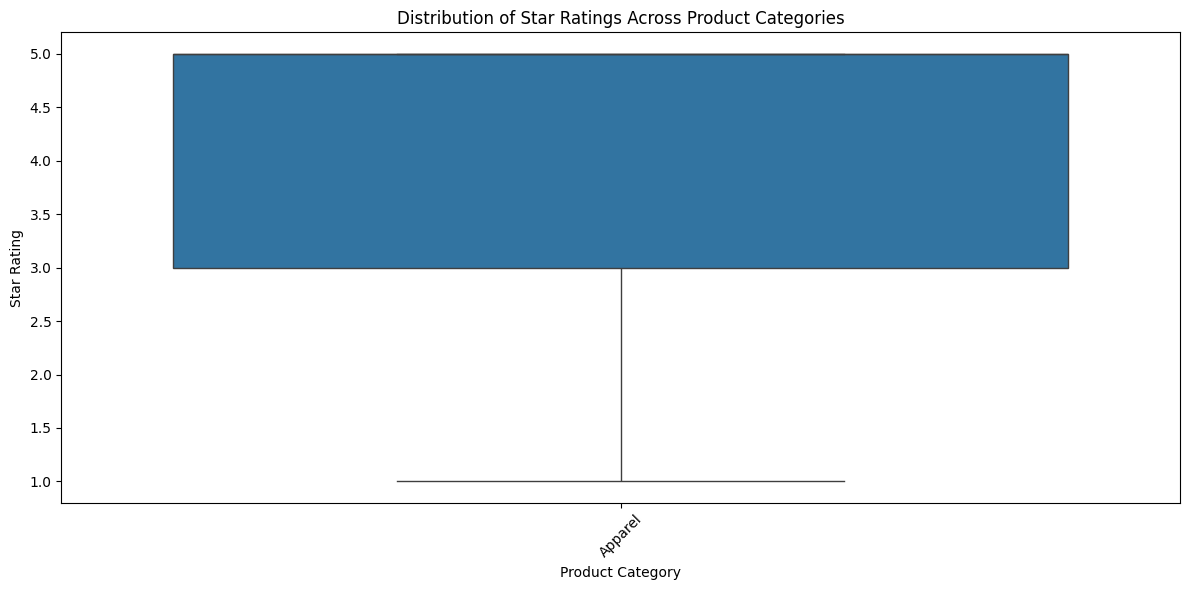

In [ ]:
# Box plots to analyze the distribution of star_rating across categories
plt.figure(figsize=(12, 6))
sns.boxplot(x="product_category", y="star_rating", data=df)
plt.xlabel("Product Category")
plt.ylabel("Star Rating")
plt.title("Distribution of Star Ratings Across Product Categories")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

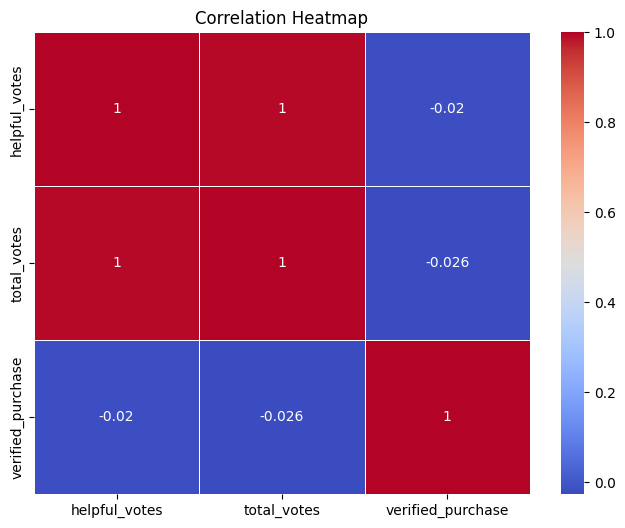

In [27]:
# heatmaps to visualize correlations between helpful_votes, total_votes, and verified_purchase
plt.figure(figsize=(8, 6))
sns.heatmap(df[["helpful_votes", "total_votes", "verified_purchase"]].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

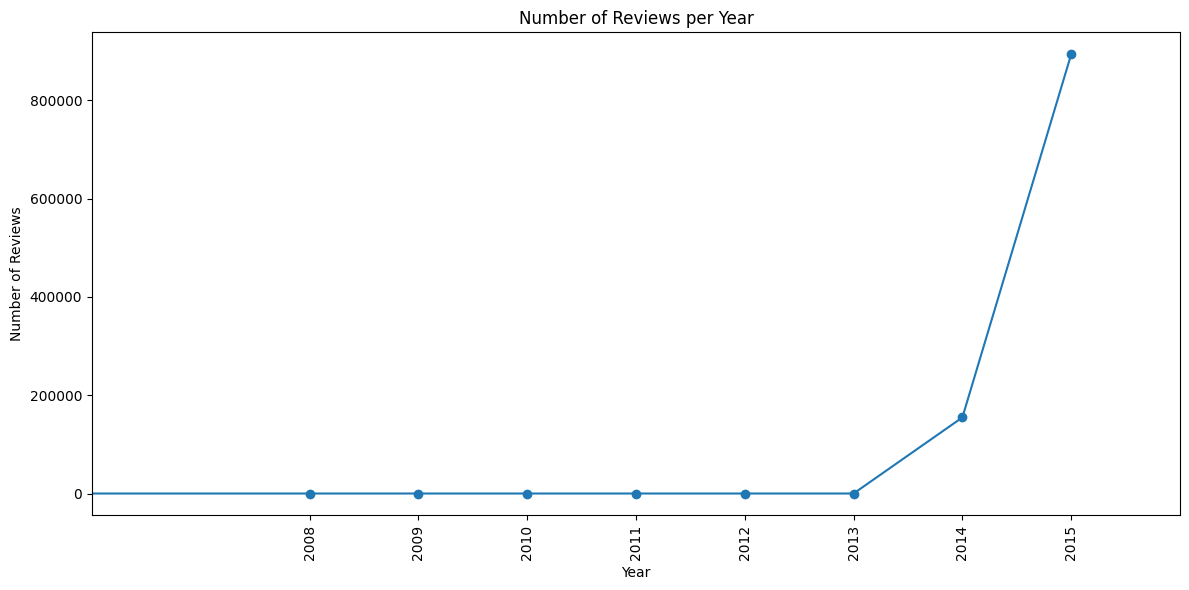

In [39]:
# Plot time-series line charts to track changes in review patterns over the years
plt.figure(figsize=(12, 6))
reviews_per_year = df.groupby("review_year").size()
reviews_per_year.plot(kind="line", marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Number of Reviews per Year")
plt.xticks(reviews_per_year.index)
plt.xticks(rotation=90)
# As the dataset contains reviews from 2007 to 2015, we can set the x-axis limits to focus on this range.
plt.xlim(2006, 2016)
plt.tight_layout()
plt.show()


5. Feature engineering & data preparation for predictive analysis
    - Create a new feature, review_length, to analyze how review length impacts helpfulness
    - Convert categorical variables (verified_purchase, vine) into numerical formats
    - Apply one-hot encoding to categorical columns like product_category
    - Normalize numerical features such as total_votes and helpful_votes using scaling techniques

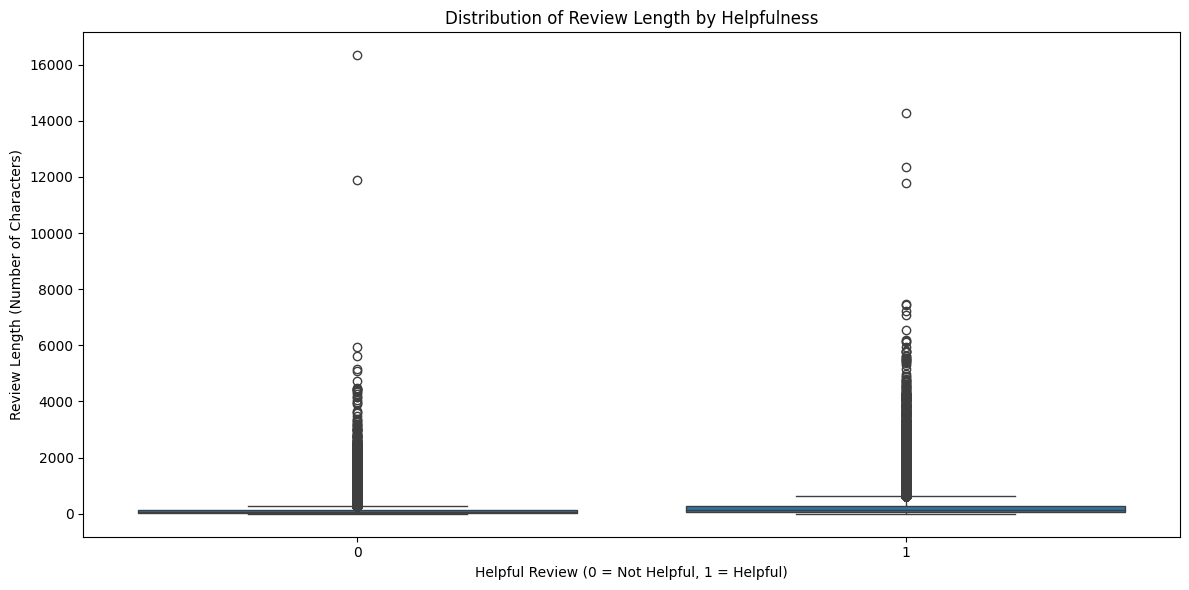

In [ ]:
# review_length and the impact on helpfulness
df["review_length"] = df["review_body"].apply(lambda x: len(str(x)))
plt.figure(figsize=(12, 6))
sns.boxplot(x="helpful_review", y="review_length", data=df)
plt.xlabel("Helpful Review (0 = Not Helpful, 1 = Helpful)")
plt.ylabel("Review Length (Number of Characters)")
plt.title("Distribution of Review Length by Helpfulness")
plt.tight_layout()
plt.show()

In [45]:
# Convert categorical variables (verified_purchase, vine) into numerical formats
# Verfied purchase is already converted to numerical format in block 11. So skipping here.
#df["verified_purchase"] = df["verified_purchase"].map({"Y": 1, "N": 0})
df["vine"] = df["vine"].map({"Y": 1, "N": 0})

In [ ]:
# Apply one-hot encoding to categorical columns like product_category
df = pd.get_dummies(df, columns=["product_category"], drop_first=True)
# As there is only one category, the one-hot encoding will not create any new columns and the original product_category is dropped.

df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,star_rating,helpful_votes,total_votes,vine,...,review_body,review_date,review_year,review_month,review_day,review_month_2014,review_month_2015,review_body_clean,helpful_review,review_length
143626,US,48444760,R2V67TZ5WAYY2M,B00UTGOD62,408553717,Fantasie Women's Smoothing Seamless Balcony Br...,1,1,2,NaN,...,I usually wear and love Fantasie bras. This pa...,2008-06-20,2008,6,20,NaN,NaN,i usually wear and love fantasie bras. this pa...,1,577
23,US,13419529,R2Q9269XM2HQ0S,B0151Z12GO,734090834,Levi's Men's 501 Original-Fit Jean,5,0,0,NaN,...,Excellent one from Levi's,2008-12-06,2008,12,6,NaN,NaN,excellent one from levi's,0,25
16041,US,49966480,R2XKUIS12Q2YVZ,B00ZXRB5HC,125151899,Olga Women's Luxury Lift Underwire Bra,5,0,0,NaN,...,Perfect. So comfortable,2009-11-30,2009,11,30,NaN,NaN,perfect. so comfortable,0,23
208320,US,51454671,R3PTJ24DZJ2939,B00TEQ2WV6,985487035,Carhartt Men's Acrylic Knit Hat A205,5,0,0,NaN,...,"it's 10% lighter than on photo, , very good lo...",2010-03-22,2010,3,22,NaN,NaN,"it's 10 lighter than on photo, , very good loo...",0,76
2569,US,28319241,R1UVFLMZUPBPWB,B012E6AR8M,240845681,Barely There Women's Microfiber Hi Cut Panty,5,0,0,NaN,...,I bought 3 of them and would buy 3 more comfor...,2011-04-30,2011,4,30,NaN,NaN,i bought 3 of them and would buy 3 more comfor...,0,65


In [ ]:
# Normalize numerical features such as total_votes and helpful_votes using scaling techniques
numerical_columns = ['total_votes', 'helpful_votes']

scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,star_rating,helpful_votes,total_votes,vine,...,review_body,review_date,review_year,review_month,review_day,review_month_2014,review_month_2015,review_body_clean,helpful_review,review_length
143626,US,48444760,R2V67TZ5WAYY2M,B00UTGOD62,408553717,Fantasie Women's Smoothing Seamless Balcony Br...,1,-0.002217,0.08835,NaN,...,I usually wear and love Fantasie bras. This pa...,2008-06-20,2008,6,20,NaN,NaN,i usually wear and love fantasie bras. this pa...,1,577
23,US,13419529,R2Q9269XM2HQ0S,B0151Z12GO,734090834,Levi's Men's 501 Original-Fit Jean,5,-0.120908,-0.13835,NaN,...,Excellent one from Levi's,2008-12-06,2008,12,6,NaN,NaN,excellent one from levi's,0,25
16041,US,49966480,R2XKUIS12Q2YVZ,B00ZXRB5HC,125151899,Olga Women's Luxury Lift Underwire Bra,5,-0.120908,-0.13835,NaN,...,Perfect. So comfortable,2009-11-30,2009,11,30,NaN,NaN,perfect. so comfortable,0,23
208320,US,51454671,R3PTJ24DZJ2939,B00TEQ2WV6,985487035,Carhartt Men's Acrylic Knit Hat A205,5,-0.120908,-0.13835,NaN,...,"it's 10% lighter than on photo, , very good lo...",2010-03-22,2010,3,22,NaN,NaN,"it's 10 lighter than on photo, , very good loo...",0,76
2569,US,28319241,R1UVFLMZUPBPWB,B012E6AR8M,240845681,Barely There Women's Microfiber Hi Cut Panty,5,-0.120908,-0.13835,NaN,...,I bought 3 of them and would buy 3 more comfor...,2011-04-30,2011,4,30,NaN,NaN,i bought 3 of them and would buy 3 more comfor...,0,65



#### Section 2: Machine learning models
1. Data preprocessing & feature engineering
    - Clean missing values in review_body, star_rating, and total_votes
    - Convert text data into numerical features using TF-IDF or word embeddings
    - Extract features like review length, sentiment polarity, and helpfulness score
    - Apply one-hot encoding to categorical variables such as verified_purchase
2. Exploratory Data Analysis (EDA) & visualization
    - Analyze rating distributions across product categories
    - Visualize word frequency in reviews using word clouds
    - Plot helpful_votes against review_length to identify trends in review usefulness
    - Use heatmaps and pair plots to study feature correlations
3. Supervised Learning: Regression models
    - Implement Linear Regression to predict star ratings
    - Apply Lasso and Ridge regression for feature selection and regularization
    - Evaluate models using R-squared, MSE, and RMSE metrics
4. Supervised Learning: Classification models
    - Build a Logistic Regression model to classify reviews as positive, neutral, or negative
    - Train Decision Trees and Random Forests for sentiment analysis
    - Use Naïve Bayes and K-Nearest Neighbors (KNN) for classification tasks
    - Evaluate models using accuracy, precision, recall, and F1-score
5. Handling imbalanced data in classification
    - Apply SMOTE (Synthetic Minority Over-sampling Technique) for balancing datasets
    - Use undersampling techniques to manage class imbalance
    - Experiment with class weighting to improve model performance
6. Ensemble Learning & model optimization
    - Implement Bagging with Random Forest for robust predictions
    - Apply Boosting techniques (AdaBoost, Gradient Boosting) to enhance accuracy
    - Combine models using Stacking for improved performance
    - Perform hyperparameter tuning with GridSearchCV
 
#### Section 3: Deep learning and advanced models
1. Neural Networks and Deep Neural Networks (DNNs)
    - Implement perceptron-based models for predicting product ratings
    - Use activation functions to optimize model performance
    - Apply forward propagation and backpropagation for neural network training
    - Optimize loss functions using Gradient Descent
    - Regularize DNNs with L1, L2 regularization, and dropout techniques
2. Deep learning frameworks (TensorFlow, Keras, PyTorch)
    - Build DNN models using TensorFlow and Keras
    - Train and evaluate models with review text data
    - Compare PyTorch and TensorFlow implementations for efficiency
    - Apply batch normalization and early stopping to prevent overfitting
3. Convolutional Neural Networks (CNNs) for image classification
    - Preprocess image data for CNN-based tasks
    - Train CNN models to classify e-commerce product images
    - Implement ResNet for enhanced performance
    - Use image augmentation to improve model generalization
4. Object detection with YOLO
    - Understand object detection techniques in e-commerce
    - Train YOLO models to detect multiple objects in product images
    - Prepare datasets and annotations for object detection tasks
    - Convert TensorFlow models to TensorFlow Lite for deployment
5. Sequential modeling with RNNs and LSTMs
    - Implement RNNs for text classification
    - Train LSTM models to predict customer sentiments
    - Optimize performance using Gated Recurrent Units (GRUs)
    - Apply hybrid CRNN models for video-based product recommendations
6. Transfer learning for product categorization
    - Use pretrained models for transfer learning
    - Train models to classify product categories
    - Fine-tune CNN models to improve classification accuracy
    - Deploy transfer learning models in real-world applications

#### Section 4: Large Language Models (LLMs) and retrieval-based AI
1. Data preprocessing & retrieval setup
    - Load and preprocess datasets with product_title and related metadata
    - Implement fuzzy matching for retrieving relevant product details
    - Use vector databases (FAISS, Pinecone) to manage product embeddings
2. Prompt engineering for LLM optimization
    - Design structured prompts to generate high-quality product descriptions
    - Apply temperature and top-k sampling to enhance response diversity
3. Retrieval-Augmented Generation (RAG) implementation
    - Integrate retrieval-based search with LLM-generated content
    - Use LangChain or similar frameworks for RAG workflows
    - Fine-tune retrieval systems to improve result relevance
4. LLM fine-tuning & model selection
    - Fine-tune open-source LLMs (e.g., Mistral, LLaMA, Falcon) on product data
    - Adapt LLMs for e-commerce applications using transfer learning
    - Compare performance across models like GPT-4, LLaMA-2, etc
5. Application development & deployment
    - Build a simple web interface for user interaction
    - Enable product title input with AI-generated descriptions
    - Integrate real-time feedback for continuous model improvement